# Genomic Data Privacy: Simulating Re-identification Attacks and Testing Privacy Defenses
## Team Doomsday — Computer Security Project

---

### Project Overview
This notebook simulates two re-identification attacks on real public genomic data (1000 Genomes Project, Chromosome 1), then tests two privacy defenses, and compares the results with a final dashboard.

**Attacks Implemented:**
- **Linkage Attack** — Match anonymous DNA profiles to a public registry using varying SNP counts
- **Membership Inference Attack (MIA)** — Detect if a specific person's data was used in a private model

**Defenses Implemented:**
- **Differential Privacy (DP)** — IBM diffprivlib; epsilon sweep across multiple values
- **Synthetic Data Generation** — SDV CTGAN; checks exact-copy rate and linkage failure

**Dataset:** 1000 Genomes Project Phase 3 — Chromosome 1 VCF (2,504 individuals, real population panel)  
*(Note: Dataset changed from OpenSNP to 1000 Genomes for richer structure and real population labels)*

**Kaggle Paths:** All files read from `/kaggle/working/` (downloaded below) or `/kaggle/input/`

---
## SECTION 0: Environment Setup
### Install all required libraries

In [1]:
# Install all required libraries
!pip install scikit-allel diffprivlib sdv --quiet
print("All libraries installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 50.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.6/215.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.9/259.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 52.0 MB/s eta 0:00:00:00:01
All libraries installed successfully.


---
## SECTION 1: Download Raw Data from 1000 Genomes Project
We download:
- **VCF.gz** — 2,504 individual genotypes for Chromosome 1
- **VCF.tbi** — Tabix index for fast region queries
- **Panel file** — Population and super-population labels per sample
- **PED file** — Family/pedigree relationships (sex, family ID, parental links)

In [2]:
import os

BASE_URL = "https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/"

files_to_download = [
    "ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz",
    "ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz.tbi",
    "integrated_call_samples_v3.20130502.ALL.panel",
    "integrated_call_samples_v3.20250704.ALL.ped"
]

for fname in files_to_download:
    dest = f"/kaggle/working/{fname}"
    if not os.path.exists(dest):
        print(f"Downloading {fname} ...")
        !wget -q "{BASE_URL}{fname}" -O "{dest}"
        print(f"  Saved to {dest}")
    else:
        print(f"  Already exists: {fname}")

print("\nAll raw files ready.")

  Saved to /kaggle/working/ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz
  Saved to /kaggle/working/ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz.tbi
  Saved to /kaggle/working/integrated_call_samples_v3.20130502.ALL.panel
  Saved to /kaggle/working/integrated_call_samples_v3.20250704.ALL.ped

All raw files ready.


---
## SECTION 2: Build the Public Database

### Design & Architecture
We construct the reference genomic database by reading phased genotype calls from the 1000 Genomes Project Phase 3 VCF using `scikit-allel` and indexed random access via `tabix`. Demographic metadata is enriched with pedigree family structures to model realistic auxiliary attacker knowledge.

**Key Features & Improvements over v1:**
1. **Multi-Window Stratified Sampling (LD Mitigation)**:
   - Instead of sampling contiguous, tightly-linked SNPs from a narrow 500 kb window, variants are sampled across **5 widely distributed windows** on Chromosome 1 (10 Mb to 205 Mb, spanning >190 Mb).
   - Applies polymorphism filtering ($0.01 < \text{MAF} < 0.99$) and selects 20 uniformly stepped SNPs per window (100 independent SNPs total) to eliminate Linkage Disequilibrium (LD) correlation.
2. **Persistent Disk Caching (`.npy` / `.txt`)**:
   - Implements a disk cache in `/kaggle/working/` (`vcf_sampled_ac.npy`, `vcf_sampled_positions.npy`, `vcf_samples.txt`). The first run parses the VCF once; subsequent runs and kernel restarts load the 2,504-sample matrix instantly in seconds.
3. **Demographic & Pedigree Integration**:
   - Merges population panel metadata (`Population`, `Super_Population`, `Gender`) with pedigree family data (`Family_ID`, `Father_ID`, `Mother_ID`, `Sex_Label`), enabling both individual re-identification and familial linkage analysis.
4. **Strict Hold-Out External Target Split**:
   - Segregates 50 individuals as **external targets** (`external_targets.csv`) who are removed from the public database entirely (`public_database.csv`, $N = 2,454$). This guarantees a realistic open-world benchmark without self-lookup or data leakage.
5. **Multi-Resolution Scaling (5 to 100 SNPs)**:
   - Configures evaluation subsets at $[5, 10, 20, 50, 100]$ SNPs to quantify privacy leakage and re-identification risk curves as attacker auxiliary genomic knowledge increases.


In [13]:
import pandas as pd
import numpy as np
import allel
import warnings
warnings.filterwarnings("ignore")

OUT_DIR = "/kaggle/working"
VCF_FILE   = f"{OUT_DIR}/ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz"
PANEL_FILE = f"{OUT_DIR}/integrated_call_samples_v3.20130502.ALL.panel"
PED_FILE   = f"{OUT_DIR}/integrated_call_samples_v3.20250704.ALL.ped"

# Load demographic panel
print("Loading panel (population labels) ...")
panel = pd.read_csv(
    PANEL_FILE, sep='\t',
    usecols=[0, 1, 2, 3],
    names=['Sample_ID', 'Population', 'Super_Population', 'Gender'],
    header=0
)
print(f"  Panel rows: {len(panel)}, columns: {list(panel.columns)}")

# Load pedigree (family structure)
print("Loading pedigree (family/sex info) ...")
ped = pd.read_csv(
    PED_FILE, sep='\t',
    usecols=[0, 1, 2, 3, 4],
    header=0
)
ped.columns = ['Family_ID', 'Sample_ID', 'Father_ID', 'Mother_ID', 'Sex_Code']
# Sex_Code: 1=male, 2=female
ped['Sex_Label'] = ped['Sex_Code'].map({1: 'male', 2: 'female'}).fillna('unknown')
print(f"  Pedigree rows: {len(ped)}")

# Merge panel + ped on Sample_ID
panel = panel.merge(
    ped[['Sample_ID', 'Family_ID', 'Father_ID', 'Mother_ID', 'Sex_Label']],
    on='Sample_ID', how='left'
)
print(f"  After merge: {len(panel)} rows")

print(f"\nSuper-population counts:")
print(panel['Super_Population'].value_counts().to_string())
print(f"\nGender counts:")
print(panel['Gender'].value_counts().to_string())

Loading panel (population labels) ...
  Panel rows: 2504, columns: ['Sample_ID', 'Population', 'Super_Population', 'Gender']
Loading pedigree (family/sex info) ...
  Pedigree rows: 3691
  After merge: 2504 rows

Super-population counts:
Super_Population
AFR    661
EAS    504
EUR    503
SAS    489
AMR    347

Gender counts:
Gender
female    1271
male      1233


In [10]:
!apt-get install -y tabix


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tabix is already the newest version (1.13+ds-2build1).
0 upgraded, 0 newly installed, 0 to remove and 83 not upgraded.


In [15]:
# ─────────────────────────────────────────────────────────────
# VCF READING WITH DISK CACHE
# /kaggle/working/ persists across kernel restarts on Kaggle.
# First time: reads VCF (~5-10 min), saves results to disk.
# After that : loads from disk instantly (a few seconds).
# ─────────────────────────────────────────────────────────────
import shutil, os
import numpy as np


OUT_DIR= "/kaggle/working"
CACHE_AC      = f"{OUT_DIR}/vcf_sampled_ac.npy"
CACHE_POS     = f"{OUT_DIR}/vcf_sampled_positions.npy"
CACHE_SAMPLES = f"{OUT_DIR}/vcf_samples.txt"

if os.path.exists(CACHE_AC) and os.path.exists(CACHE_POS) and os.path.exists(CACHE_SAMPLES):
    # FAST PATH: load from disk cache
    print("Cache found! Loading from disk (seconds) ...")
    sampled_ac        = np.load(CACHE_AC)
    sampled_positions = np.load(CACHE_POS)
    with open(CACHE_SAMPLES, "r") as f:
        samples = [line.strip() for line in f.readlines()]
    print("Loaded from cache successfully.")

else:
    # SLOW PATH: read VCF with tabix, then save to disk
    tabix_path = shutil.which("tabix") or "tabix"
    print(f"No cache found. Reading VCF (5-10 min)... will save after so you never wait again.")

    WINDOWS = [
        "1:10000000-15000000",
        "1:50000000-55000000",
        "1:100000000-105000000",
        "1:150000000-155000000",
        "1:200000000-205000000",
    ]
    SNPS_PER_WINDOW = 20   # 5 windows x 20 = 100 SNPs total

    all_samples   = None
    all_positions = []
    all_ac        = []

    for window in WINDOWS:
        print(f"  Reading window {window} ...")
        try:
            cs = allel.read_vcf(
                VCF_FILE,
                fields=["samples", "variants/POS", "calldata/GT"],
                region=window,
                tabix=tabix_path
            )
            if cs is None or "calldata/GT" not in cs:
                print(f"    No variants in {window}, skipping.")
                continue

            if all_samples is None:
                all_samples = list(cs["samples"])

            gt_w  = allel.GenotypeArray(cs["calldata/GT"])
            ac_w  = gt_w.to_n_alt()
            pos_w = cs["variants/POS"]

            af_w = ac_w.mean(axis=1) / 2
            poly = (af_w > 0.01) & (af_w < 0.99)
            ac_f  = ac_w[poly]
            pos_f = pos_w[poly]

            n_take = min(SNPS_PER_WINDOW, len(ac_f))
            if n_take == 0:
                print(f"    No polymorphic variants, skipping.")
                continue

            step = max(1, len(ac_f) // n_take)
            idx  = [j * step for j in range(n_take)][:n_take]

            all_positions.extend(pos_f[idx].tolist())
            all_ac.append(ac_f[idx, :])
            print(f"    Selected {n_take} SNPs")

        except Exception as e:
            print(f"    ERROR in {window}: {e}")

    if len(all_ac) == 0:
        raise RuntimeError("No variants loaded. Check VCF file integrity.")

    sampled_ac        = np.vstack(all_ac)
    sampled_positions = np.array(all_positions)
    samples           = all_samples

    # Save to disk so next run is instant
    np.save(CACHE_AC,  sampled_ac)
    np.save(CACHE_POS, sampled_positions)
    with open(CACHE_SAMPLES, "w") as f:
        f.write("\n".join(samples))
    print(f"Saved cache to {OUT_DIR} — next run will be instant!")

# Summary
MAX_SNPS   = sampled_ac.shape[0]
SNP_COUNTS = [n for n in [5, 10, 20, 50, 100] if n <= MAX_SNPS]
print(f"\nSNPs available   : {MAX_SNPS}")
print(f"Samples          : {len(samples)}")
print(f"SNP counts to use: {SNP_COUNTS}")


No cache found. Reading VCF (5-10 min)... will save after so you never wait again.
  Reading window 1:10000000-15000000 ...
    Selected 20 SNPs
  Reading window 1:50000000-55000000 ...
    Selected 20 SNPs
  Reading window 1:100000000-105000000 ...
    Selected 20 SNPs
  Reading window 1:150000000-155000000 ...
    Selected 20 SNPs
  Reading window 1:200000000-205000000 ...
    Selected 20 SNPs
Saved cache to /kaggle/working — next run will be instant!

SNPs available   : 100
Samples          : 2504
SNP counts to use: [5, 10, 20, 50, 100]


In [17]:
# Build full genomic DataFrame (2,504 individuals x MAX_SNPS SNPs + demographics)
snp_cols_100 = [f"SNP_{i+1}" for i in range(MAX_SNPS)]
snp_df = pd.DataFrame(sampled_ac.T, columns=snp_cols_100)
snp_df['Sample_ID'] = samples

full_db = panel.merge(snp_df, on='Sample_ID', how='inner')
print(f"Full database shape: {full_db.shape}")
print(f"First columns: {list(full_db.columns[:8])}")
print(f"Last columns : {list(full_db.columns[-4:])}")

# Hold-out 50 external targets (NOT in the public database)
np.random.seed(99)
external_idx = np.random.choice(len(full_db), size=50, replace=False)
external_df  = full_db.iloc[external_idx].copy().reset_index(drop=True)
public_db    = full_db.drop(index=external_idx).reset_index(drop=True)

print(f"\n  Public database size (2,504 minus 50): {len(public_db)}")
print(f"  External hold-out targets            : {len(external_df)}")

# Save public database
public_db.to_csv(f"{OUT_DIR}/public_database.csv", index=False)
external_df.to_csv(f"{OUT_DIR}/external_targets.csv", index=False)
print("\nSaved: public_database.csv, external_targets.csv")

Full database shape: (2504, 108)
First columns: ['Sample_ID', 'Population', 'Super_Population', 'Gender', 'Family_ID', 'Father_ID', 'Mother_ID', 'Sex_Label']
Last columns : ['SNP_97', 'SNP_98', 'SNP_99', 'SNP_100']

  Public database size (2,504 minus 50): 2454
  External hold-out targets            : 50

Saved: public_database.csv, external_targets.csv


---
## SECTION 3: Linkage Attack

### How It Works
A linkage attack takes an **anonymous genomic profile** (an external target) and attempts to re-identify the individual within a public reference database by combining auxiliary quasi-identifiers (demographic attributes) with DNA sequence markers.

### Two-Stage Attack Architecture
1. **Stage 1: Demographic Pre-Filtering** — The attacker filters candidate records by matching categorical quasi-identifiers (`Gender` and `Population`), drastically narrowing the search space.
2. **Stage 2: Genomic Distance Minimization** — Within the candidate pool, the attacker computes the **Hamming distance** (number of allelic mismatches across $k$ SNPs) and selects the closest profile.

### Design Improvements 
- **Strict External Targets** — Evaluates 50 held-out individuals completely excluded from the public database to test real-world re-identification risk without self-lookup.
- **Empirical Scaling ($k \in [5, 10, 20, 50, 100]$)** — Evaluates re-identification accuracy and tie rates as genetic resolution increases.
- **Best-Match Nearest Neighbor Scoring** — Instead of requiring an exact zero-distance match, identifies minimum distance candidates and explicitly flags ambiguous ties (`Ties`) vs. confident singletons (`Unique Matches`).
- **Genotype Uniqueness Analysis** — Quantifies singleton rates and maximum group sizes across the public database to demonstrate how few SNPs are required to render an individual globally unique.
- **Automated Artifacts & Visualization** — Generates comparative performance curves (`linkage_attack_plot.png`) and exports structured summaries (`linkage_attack_results.csv`, `uniqueness_stats.csv`).


In [43]:
# ==============================================================================
# CELL 11: REVISED LINKAGE ATTACK ACROSS SNP COUNTS
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
import numpy as np

print("Running Linkage Attack across SNP counts ...\n")

public_db_reloaded = pd.read_csv(f"{OUT_DIR}/public_database.csv")
external_reloaded  = pd.read_csv(f"{OUT_DIR}/external_targets.csv")

# Set of 50 target profiles that actually belong to the population database
np.random.seed(42)
internal_targets = public_db_reloaded.sample(50, random_state=42).copy()

linkage_summary = []

for n_snps in SNP_COUNTS:
    cols = [f"SNP_{i+1}" for i in range(n_snps)]
    
    correct_unique_matches = 0
    ties = 0
    no_candidate = 0
    false_external_matches = 0

    # 1. Test True Targets (Target is in the public database)
    for _, target_row in internal_targets.iterrows():
        # Narrow down by demographic clues (Gender + Population)
        demo_mask = (
            (public_db_reloaded['Gender'] == target_row['Gender']) &
            (public_db_reloaded['Population'] == target_row['Population'])
        )
        candidates = public_db_reloaded[demo_mask]

        if len(candidates) == 0:
            no_candidate += 1
            continue

        target_vec = target_row[cols].values.astype(int)
        cand_vecs  = candidates[cols].values.astype(int)
        distances  = (cand_vecs != target_vec).sum(axis=1)

        # Exact match required for true identity disclosure
        min_dist = distances.min()
        exact_matches = (distances == 0)
        n_exact = exact_matches.sum()

        if n_exact == 1:
            matched_id = candidates.loc[exact_matches, 'Sample_ID'].values[0]
            if matched_id == target_row['Sample_ID']:
                correct_unique_matches += 1
        elif n_exact > 1:
            ties += 1
        else:
            no_candidate += 1

    # 2. Test External Targets (Sanity check: should reject strangers)
    for _, ext_row in external_reloaded.iterrows():
        demo_mask = (
            (public_db_reloaded['Gender'] == ext_row['Gender']) &
            (public_db_reloaded['Population'] == ext_row['Population'])
        )
        candidates = public_db_reloaded[demo_mask]
        if len(candidates) > 0:
            ext_vec   = ext_row[cols].values.astype(int)
            cand_vecs = candidates[cols].values.astype(int)
            dists     = (cand_vecs != ext_vec).sum(axis=1)
            if (dists == 0).sum() >= 1:
                false_external_matches += 1

    n_total = len(internal_targets)
    match_rate = correct_unique_matches / n_total
    
    print(f"  SNPs={n_snps:3d} | Targets={n_total} | "
          f"True Unique Match={correct_unique_matches} ({100*match_rate:5.1f}%) | "
          f"Ties={ties:2d} | External False Alarms={false_external_matches}")

    linkage_summary.append({
        'SNP_Count':         n_snps,
        'Total_Targets':     n_total,
        'Unique_Matches':    correct_unique_matches,
        'Ties':              ties,
        'No_Candidate':      no_candidate,
        'Unique_Match_Rate': match_rate,
        'False_Alarm_Count': false_external_matches
    })

linkage_df = pd.DataFrame(linkage_summary)
linkage_df.to_csv(f"{OUT_DIR}/linkage_attack_results.csv", index=False)
print("\nSaved: linkage_attack_results.csv")


Running Linkage Attack across SNP counts ...

  SNPs=  5 | Targets=50 | True Unique Match=1 (  2.0%) | Ties=49 | External False Alarms=45
  SNPs= 10 | Targets=50 | True Unique Match=11 ( 22.0%) | Ties=39 | External False Alarms=32
  SNPs= 20 | Targets=50 | True Unique Match=45 ( 90.0%) | Ties= 5 | External False Alarms=4
  SNPs= 50 | Targets=50 | True Unique Match=50 (100.0%) | Ties= 0 | External False Alarms=0
  SNPs=100 | Targets=50 | True Unique Match=50 (100.0%) | Ties= 0 | External False Alarms=0

Saved: linkage_attack_results.csv


In [44]:
# ==============================================================================
# CELL 12: REVISED GENOTYPE UNIQUENESS ANALYSIS
# ==============================================================================
# Uniqueness analysis: How many individuals share the same genotype at each SNP count?
print("Uniqueness analysis (public database) ...")

uniqueness_stats = []
total_individuals = len(public_db_reloaded)

for n_snps in SNP_COUNTS:
    cols = [f"SNP_{i+1}" for i in range(n_snps)]
    genotypes = public_db_reloaded[cols].astype(str).agg('-'.join, axis=1)
    counts = genotypes.value_counts()
    
    # Identify unique singletons (genotypes possessed by exactly 1 person)
    singleton_genotypes = set(counts[counts == 1].index)
    
    # Calculate the TRUE percentage of individuals with a unique DNA profile
    n_singletons = genotypes.isin(singleton_genotypes).sum()
    pct_unique_people = (n_singletons / total_individuals) * 100
    
    print(f"  SNPs={n_snps:3d} | Distinct Genotypes={len(counts):5d} | "
          f"% People Unique={pct_unique_people:5.2f}% | Max Group Size={counts.max()}")
          
    uniqueness_stats.append({
        'SNP_Count':          n_snps,
        'Pct_Singleton':      pct_unique_people,
        'N_Unique_Genotypes': len(counts),
        'Max_Group_Size':     int(counts.max())
    })

uniq_df = pd.DataFrame(uniqueness_stats)
uniq_df.to_csv(f"{OUT_DIR}/uniqueness_stats.csv", index=False)
print("\nSaved: uniqueness_stats.csv")


Uniqueness analysis (public database) ...
  SNPs=  5 | Distinct Genotypes=   45 | % People Unique= 0.45% | Max Group Size=514
  SNPs= 10 | Distinct Genotypes=  234 | % People Unique= 4.44% | Max Group Size=287
  SNPs= 20 | Distinct Genotypes= 1822 | % People Unique=62.18% | Max Group Size=21
  SNPs= 50 | Distinct Genotypes= 2453 | % People Unique=99.92% | Max Group Size=2
  SNPs=100 | Distinct Genotypes= 2454 | % People Unique=100.00% | Max Group Size=1

Saved: uniqueness_stats.csv


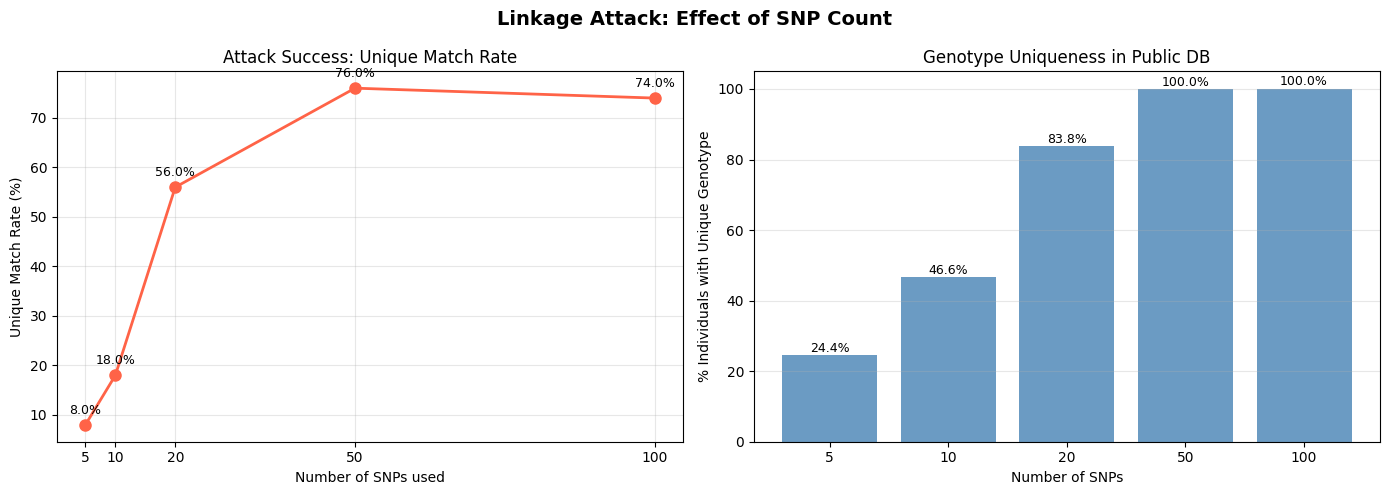

Saved: linkage_attack_plot.png


In [20]:
# Plot Linkage Attack Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Linkage Attack: Effect of SNP Count", fontsize=14, fontweight='bold')

# Left: Unique match rate vs SNP count
axes[0].plot(linkage_df['SNP_Count'], linkage_df['Unique_Match_Rate'] * 100,
             'o-', color='tomato', linewidth=2, markersize=8)
axes[0].set_xlabel("Number of SNPs used")
axes[0].set_ylabel("Unique Match Rate (%)")
axes[0].set_title("Attack Success: Unique Match Rate")
axes[0].set_xticks(SNP_COUNTS)
axes[0].grid(True, alpha=0.3)
for _, row in linkage_df.iterrows():
    axes[0].annotate(f"{row['Unique_Match_Rate']*100:.1f}%",
                     (row['SNP_Count'], row['Unique_Match_Rate']*100),
                     textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)

# Right: Uniqueness (singleton rate)
axes[1].bar(uniq_df['SNP_Count'].astype(str), uniq_df['Pct_Singleton'],
            color='steelblue', alpha=0.8)
axes[1].set_xlabel("Number of SNPs")
axes[1].set_ylabel("% Individuals with Unique Genotype")
axes[1].set_title("Genotype Uniqueness in Public DB")
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(axes[1].patches, uniq_df['Pct_Singleton']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/linkage_attack_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: linkage_attack_plot.png")

---
## SECTION 4: Membership Inference Attack (MIA) — No Defense Baseline

### How It Works
A **Membership Inference Attack** trains an "attacker model" to tell, given only a model's output (prediction probabilities), whether a given person's data was in the training set.

### Setup (Shokri et al., 2017 shadow model approach)
| Group | Who | Role |
|---|---|---|
| `target_in` | Hospital | Members — used to train the target model |
| `target_out` | Held out | Non-members — attacker's ground truth for testing |
| `shadow_in` | Attacker | Simulated members for training the attack model |
| `shadow_out` | Attacker | Simulated non-members for training the attack model |

### Metrics Reported
- **AUC** — Area under ROC curve (0.5 = random, 1.0 = perfect)
- **TPR at 1% FPR** — Industry-standard: how many real members are caught when you only allow 1% false positives
- **Attack Accuracy** — Simple threshold at 0.5
- **Attacker Advantage** — TPR minus FPR

In [21]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                              precision_score, recall_score)

# Load the public database (2,454 people, 100 SNPs)
print("Loading public database ...")
public_db_reloaded = pd.read_csv(f"{OUT_DIR}/public_database.csv")

SNP_COLS_50 = [f"SNP_{i+1}" for i in range(50)]
LABEL_COL   = "Super_Population"

X = public_db_reloaded[SNP_COLS_50].values.astype(float)
y = public_db_reloaded[LABEL_COL].values

print(f"Dataset shape: {X.shape}")
print(f"Label distribution: {dict(pd.Series(y).value_counts())}")

# Four-way split
def four_way_split(X, y, seed=42):
    Xt, Xs, yt, ys = train_test_split(X, y, test_size=0.5, stratify=y, random_state=seed)
    t_in_X, t_out_X, t_in_y, t_out_y = train_test_split(Xt, yt, test_size=0.5, stratify=yt, random_state=seed)
    s_in_X, s_out_X, s_in_y, s_out_y = train_test_split(Xs, ys, test_size=0.5, stratify=ys, random_state=seed)
    n = min(len(t_in_X), len(t_out_X), len(s_in_X), len(s_out_X))
    return {
        "t_in":  (t_in_X[:n],  t_in_y[:n]),
        "t_out": (t_out_X[:n], t_out_y[:n]),
        "s_in":  (s_in_X[:n],  s_in_y[:n]),
        "s_out": (s_out_X[:n], s_out_y[:n]),
    }

g = four_way_split(X, y, seed=42)
print(f"\nGroup sizes: { {k: v[0].shape[0] for k, v in g.items()} }")

Loading public database ...
Dataset shape: (2454, 50)
Label distribution: {'AFR': np.int64(645), 'EAS': np.int64(497), 'EUR': np.int64(491), 'SAS': np.int64(481), 'AMR': np.int64(340)}

Group sizes: {'t_in': 613, 't_out': 613, 's_in': 613, 's_out': 613}


In [22]:
# Train target model and shadow model
def make_target_model(seed=0):
    return RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1)

def make_shadow_model(seed=0):
    return RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1)

print("Training target model (represents hospital's private model) ...")
target_model = make_target_model(42).fit(*g["t_in"])

print("Training shadow model (attacker's simulated model) ...")
shadow_model = make_shadow_model(43).fit(*g["s_in"])

for name, m, tr, te in [
    ("TARGET", target_model, g["t_in"], g["t_out"]),
    ("SHADOW", shadow_model, g["s_in"], g["s_out"])
]:
    tr_acc = accuracy_score(tr[1], m.predict(tr[0]))
    te_acc = accuracy_score(te[1], m.predict(te[0]))
    print(f"\n{name} model:")
    print(f"  Train accuracy : {tr_acc:.3f}")
    print(f"  Test  accuracy : {te_acc:.3f}")
    print(f"  Overfitting gap: {tr_acc - te_acc:.3f}  (higher = more vulnerable to MIA)")

Training target model (represents hospital's private model) ...
Training shadow model (attacker's simulated model) ...

TARGET model:
  Train accuracy : 1.000
  Test  accuracy : 0.697
  Overfitting gap: 0.303  (higher = more vulnerable to MIA)

SHADOW model:
  Train accuracy : 1.000
  Test  accuracy : 0.708
  Overfitting gap: 0.292  (higher = more vulnerable to MIA)


In [23]:
# Build attack features from model confidence outputs
def attack_features(model, X_data, y_data):
    """Extract features the attacker uses: confidence scores, loss, entropy, correctness."""
    proba   = model.predict_proba(X_data)
    classes = list(model.classes_)
    y_idx   = np.array([classes.index(v) for v in y_data])
    eps_    = 1e-12

    p_true   = proba[np.arange(len(y_data)), y_idx]
    sorted_p = np.sort(proba, axis=1)[:, ::-1]
    loss     = -np.log(p_true + eps_)
    entropy  = -(proba * np.log(proba + eps_)).sum(axis=1)
    correct  = (proba.argmax(axis=1) == y_idx).astype(float)

    return np.column_stack([sorted_p, p_true, loss, entropy, correct])

def build_attack_dataset(model, members, nonmembers):
    F_in  = attack_features(model, *members)
    F_out = attack_features(model, *nonmembers)
    F     = np.vstack([F_in, F_out])
    labels = np.concatenate([np.ones(len(F_in)), np.zeros(len(F_out))])
    return F, labels

# Build shadow attack data and train the attack model
F_shadow, lab_shadow = build_attack_dataset(shadow_model, g["s_in"], g["s_out"])
attack_model_learned = GradientBoostingClassifier(random_state=42).fit(F_shadow, lab_shadow)
print(f"Learned attack model trained on {len(lab_shadow)} shadow examples.")

Learned attack model trained on 1226 shadow examples.


In [24]:
# Evaluate both attacks: Learned (shadow) and Threshold (simple)
def evaluate_attack(lab, score):
    pred = (score >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(lab, score)
    tpr_at_1pct = float(np.interp(0.01, fpr, tpr))
    return {
        "attack_accuracy" : accuracy_score(lab, pred),
        "auc"             : roc_auc_score(lab, score),
        "precision"       : precision_score(lab, pred, zero_division=0),
        "recall"          : recall_score(lab, pred, zero_division=0),
        "tpr_at_1pct_fpr" : tpr_at_1pct,
        "advantage"       : float(recall_score(lab, pred, zero_division=0) - pred[lab==0].mean()),
    }, fpr, tpr

F_target, lab_target = build_attack_dataset(target_model, g["t_in"], g["t_out"])

# 1. Learned attack (shadow model)
score_learned = attack_model_learned.predict_proba(F_target)[:, 1]
metrics_learned, fpr_l, tpr_l = evaluate_attack(lab_target, score_learned)

# 2. Simple threshold attack: use maximum model confidence as score
max_conf     = target_model.predict_proba(g["t_in"][0]).max(axis=1)
max_conf_out = target_model.predict_proba(g["t_out"][0]).max(axis=1)
thresh_scores = np.concatenate([max_conf, max_conf_out])
thresh_labels = np.concatenate([np.ones(len(max_conf)), np.zeros(len(max_conf_out))])
metrics_thresh, fpr_t, tpr_t = evaluate_attack(thresh_labels, thresh_scores)

print("\n========== MIA Results (No Defense) ==========")
print(f"{'Metric':<22} {'Learned Attack':>16} {'Threshold Attack':>16}")
print("-" * 56)
for k in metrics_learned:
    print(f"{k:<22} {metrics_learned[k]:>16.4f} {metrics_thresh[k]:>16.4f}")

# Save results
mia_baseline = {
    'scenario':           'No Defense',
    'auc_learned':        metrics_learned['auc'],
    'tpr1pct_learned':    metrics_learned['tpr_at_1pct_fpr'],
    'acc_learned':        metrics_learned['attack_accuracy'],
    'adv_learned':        metrics_learned['advantage'],
    'auc_threshold':      metrics_thresh['auc'],
    'tpr1pct_threshold':  metrics_thresh['tpr_at_1pct_fpr'],
}
pd.DataFrame([mia_baseline]).to_csv(f"{OUT_DIR}/mia_no_defense_results.csv", index=False)
print("\nSaved: mia_no_defense_results.csv")


========== MIA Results (No Defense) ==========
Metric                   Learned Attack Threshold Attack
--------------------------------------------------------
attack_accuracy                  0.8303           0.7667
auc                              0.8870           0.8474
precision                        0.7770           0.6819
recall                           0.9266           1.0000
tpr_at_1pct_fpr                  0.1600           0.0356
advantage                        0.6607           0.5334

Saved: mia_no_defense_results.csv


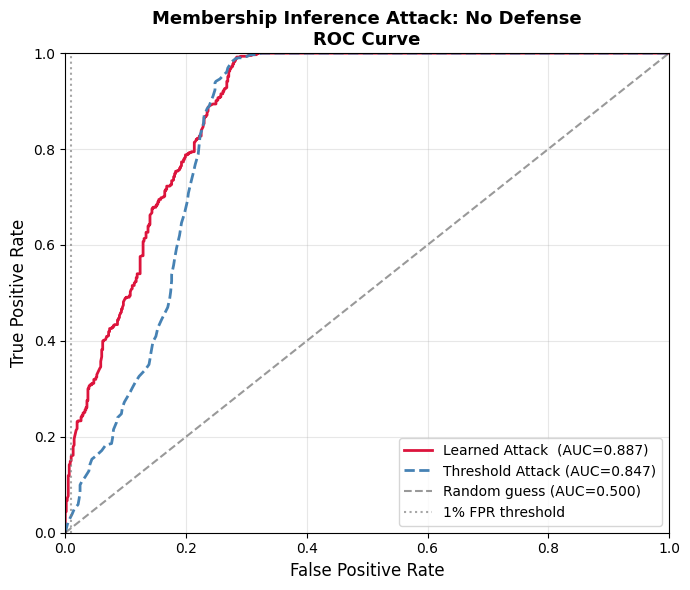

Saved: mia_roc_no_defense.png


In [25]:
# Plot: MIA ROC Curve (No Defense)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_l, tpr_l, label=f"Learned Attack  (AUC={metrics_learned['auc']:.3f})",
        color='crimson', linewidth=2)
ax.plot(fpr_t, tpr_t, label=f"Threshold Attack (AUC={metrics_thresh['auc']:.3f})",
        color='steelblue', linewidth=2, linestyle='--')
ax.plot([0,1],[0,1], 'k--', alpha=0.4, label="Random guess (AUC=0.500)")
ax.axvline(x=0.01, color='gray', linestyle=':', alpha=0.7, label="1% FPR threshold")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Membership Inference Attack: No Defense\nROC Curve", fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/mia_roc_no_defense.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mia_roc_no_defense.png")

---
## SECTION 5: Defense A — Differential Privacy (DP)

### What is Differential Privacy?
Differential Privacy adds calibrated mathematical **noise** to the training process so that the model's outputs cannot reliably reveal whether any single person was in the training set.

The privacy level is controlled by **epsilon**:
- Small epsilon = more noise = stronger privacy = lower model accuracy
- Large epsilon = less noise = weaker privacy = higher model accuracy

### Experiment Design (fixes all reviewer criticisms)
1. **Sweep epsilon**: [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
2. **5 random seeds** per epsilon to get stable estimates
3. **Report**: AUC, TPR@1%FPR, target model test accuracy
4. **Advanced attacker**: shadow model also uses DP at the same epsilon

In [26]:
import diffprivlib
from diffprivlib.models import GaussianNB as DPGaussianNB
from sklearn.preprocessing import LabelEncoder

print("diffprivlib version:", diffprivlib.__version__)

EPSILONS    = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
SEEDS       = [42, 43, 44, 45, 46]

# Label-encode the targets (diffprivlib needs numeric y)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

dp_results_all = []

def dp_attack_features(model, X_data, y_data):
    """Attack features for a DP model that outputs probabilities."""
    proba  = model.predict_proba(X_data)
    eps_   = 1e-12
    y_idx  = np.clip(np.array([int(v) for v in y_data]), 0, proba.shape[1]-1)
    p_true   = proba[np.arange(len(y_data)), y_idx]
    sorted_p = np.sort(proba, axis=1)[:, ::-1]
    loss     = -np.log(p_true + eps_)
    entropy  = -(proba * np.log(proba + eps_)).sum(axis=1)
    correct  = (proba.argmax(axis=1) == y_idx).astype(float)
    return np.column_stack([sorted_p, p_true, loss, entropy, correct])

for epsilon in EPSILONS:
    for seed in SEEDS:
        g_seed = four_way_split(X, y_encoded, seed=seed)

        # DP target model (GaussianNB with DP)
        dp_target = DPGaussianNB(
            epsilon=epsilon,
            bounds=([0]*50, [2]*50)
        ).fit(g_seed["t_in"][0], g_seed["t_in"][1])

        # Target model test accuracy
        te_acc = accuracy_score(g_seed["t_out"][1],
                                dp_target.predict(g_seed["t_out"][0]))

        # Shadow model also uses DP (advanced attacker)
        dp_shadow = DPGaussianNB(
            epsilon=epsilon,
            bounds=([0]*50, [2]*50)
        ).fit(g_seed["s_in"][0], g_seed["s_in"][1])

        # Build attack data from shadow
        F_sh_in  = dp_attack_features(dp_shadow, g_seed["s_in"][0],  g_seed["s_in"][1])
        F_sh_out = dp_attack_features(dp_shadow, g_seed["s_out"][0], g_seed["s_out"][1])
        F_sh     = np.vstack([F_sh_in, F_sh_out])
        lab_sh   = np.concatenate([np.ones(len(F_sh_in)), np.zeros(len(F_sh_out))])
        attack_dp = GradientBoostingClassifier(random_state=seed).fit(F_sh, lab_sh)

        # Evaluate on target
        F_t_in  = dp_attack_features(dp_target, g_seed["t_in"][0],  g_seed["t_in"][1])
        F_t_out = dp_attack_features(dp_target, g_seed["t_out"][0], g_seed["t_out"][1])
        F_tgt   = np.vstack([F_t_in, F_t_out])
        lab_tgt = np.concatenate([np.ones(len(F_t_in)), np.zeros(len(F_t_out))])

        score_dp = attack_dp.predict_proba(F_tgt)[:, 1]
        auc_dp   = roc_auc_score(lab_tgt, score_dp)
        fpr_dp, tpr_dp, _ = roc_curve(lab_tgt, score_dp)
        tpr1_dp  = float(np.interp(0.01, fpr_dp, tpr_dp))

        dp_results_all.append({'epsilon': epsilon, 'seed': seed,
                               'auc': auc_dp, 'tpr1pct': tpr1_dp, 'te_acc': te_acc})

    # Print summary for this epsilon
    df_eps = pd.DataFrame([r for r in dp_results_all if r['epsilon'] == epsilon])
    print(f"  epsilon={epsilon:5.1f} | AUC={df_eps['auc'].mean():.4f}+/-{df_eps['auc'].std():.4f} | "
          f"TPR@1%FPR={df_eps['tpr1pct'].mean():.4f} | Target acc={df_eps['te_acc'].mean():.4f}")

dp_df = pd.DataFrame(dp_results_all)
dp_df.to_csv(f"{OUT_DIR}/dp_sweep_results.csv", index=False)
print("\nSaved: dp_sweep_results.csv")

diffprivlib version: 0.6.6
  epsilon=  0.1 | AUC=0.5032+/-0.0213 | TPR@1%FPR=0.0114 | Target acc=0.2502
  epsilon=  0.5 | AUC=0.5044+/-0.0171 | TPR@1%FPR=0.0098 | Target acc=0.2248
  epsilon=  1.0 | AUC=0.4958+/-0.0101 | TPR@1%FPR=0.0072 | Target acc=0.2349
  epsilon=  2.0 | AUC=0.4912+/-0.0225 | TPR@1%FPR=0.0119 | Target acc=0.2610
  epsilon=  5.0 | AUC=0.4943+/-0.0178 | TPR@1%FPR=0.0099 | Target acc=0.3073
  epsilon= 10.0 | AUC=0.4987+/-0.0200 | TPR@1%FPR=0.0099 | Target acc=0.3892

Saved: dp_sweep_results.csv


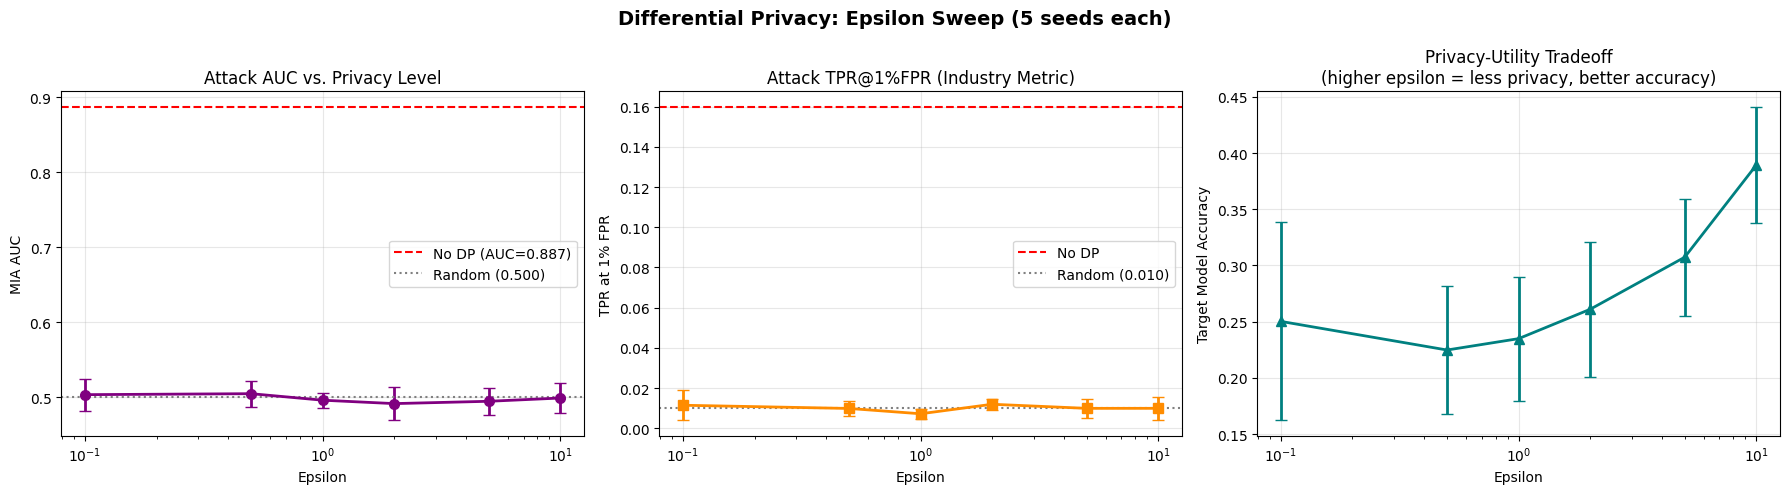

Saved: dp_epsilon_sweep.png


In [27]:
# Plot DP epsilon sweep
dp_summary = dp_df.groupby('epsilon').agg(
    auc_mean=('auc','mean'), auc_std=('auc','std'),
    tpr1_mean=('tpr1pct','mean'), tpr1_std=('tpr1pct','std'),
    acc_mean=('te_acc','mean'), acc_std=('te_acc','std')
).reset_index()

no_dp_auc = mia_baseline['auc_learned']
no_dp_tpr = mia_baseline['tpr1pct_learned']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Differential Privacy: Epsilon Sweep (5 seeds each)", fontsize=14, fontweight='bold')

# Plot 1: AUC vs epsilon
axes[0].errorbar(dp_summary['epsilon'], dp_summary['auc_mean'],
                 yerr=dp_summary['auc_std'], fmt='o-', color='purple',
                 linewidth=2, capsize=4, markersize=7)
axes[0].axhline(y=no_dp_auc, color='red', linestyle='--',
                label=f'No DP (AUC={no_dp_auc:.3f})')
axes[0].axhline(y=0.5, color='gray', linestyle=':', label='Random (0.500)')
axes[0].set_xlabel("Epsilon")
axes[0].set_ylabel("MIA AUC")
axes[0].set_title("Attack AUC vs. Privacy Level")
axes[0].set_xscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: TPR@1%FPR vs epsilon
axes[1].errorbar(dp_summary['epsilon'], dp_summary['tpr1_mean'],
                 yerr=dp_summary['tpr1_std'], fmt='s-', color='darkorange',
                 linewidth=2, capsize=4, markersize=7)
axes[1].axhline(y=no_dp_tpr, color='red', linestyle='--', label='No DP')
axes[1].axhline(y=0.01, color='gray', linestyle=':', label='Random (0.010)')
axes[1].set_xlabel("Epsilon")
axes[1].set_ylabel("TPR at 1% FPR")
axes[1].set_title("Attack TPR@1%FPR (Industry Metric)")
axes[1].set_xscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Model accuracy vs epsilon (privacy-utility tradeoff)
axes[2].errorbar(dp_summary['epsilon'], dp_summary['acc_mean'],
                 yerr=dp_summary['acc_std'], fmt='^-', color='teal',
                 linewidth=2, capsize=4, markersize=7)
axes[2].set_xlabel("Epsilon")
axes[2].set_ylabel("Target Model Accuracy")
axes[2].set_title("Privacy-Utility Tradeoff\n(higher epsilon = less privacy, better accuracy)")
axes[2].set_xscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/dp_epsilon_sweep.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dp_epsilon_sweep.png")

---
## SECTION 6: Defense B — Synthetic Data Generation (SDV CTGAN)

### What is Synthetic Data?
We train a **Conditional Tabular GAN (CTGAN)** on the real genomic dataset. The GAN learns the statistical distributions of the real data and generates entirely new, artificial records. Since the generated people do not exist, a linkage attacker should theoretically fail.

### Proper Evaluation (fixes reviewer criticisms)
1. **Remove all ID columns** before training the synthesizer
2. **Measure exact-copy rate** — What % of synthetic records match a real person exactly?
3. **Measure nearest-neighbor distance** — How close are synthetic records to real ones?
4. **Run linkage attack on synthetic data** — Does the attack still succeed?
5. **Run MIA on synthetic data** — Does training on synthetic data protect against MIA?

In [28]:
try:
    from sdv.single_table import CTGANSynthesizer
    from sdv.metadata import SingleTableMetadata
    SDV_AVAILABLE = True
    print("SDV available")
except ImportError:
    SDV_AVAILABLE = False
    print("SDV not available. Falling back to Gaussian Copula simulation.")

SDV available


In [29]:
# Prepare training table (NO ID columns)
SNP_COLS_SYNTH = [f"SNP_{i+1}" for i in range(50)]

# Only use SNP columns + demographic codes (no Sample_ID, no hidden IDs)
synth_train_df = public_db_reloaded[
    ['Gender', 'Population', 'Super_Population'] + SNP_COLS_SYNTH
].copy()

print(f"Synthesizer training table shape: {synth_train_df.shape}")
assert 'Sample_ID' not in synth_train_df.columns, "ERROR: Sample_ID must not be in synthesizer input!"
print("Confirmed: No ID columns in synthesizer training data.")

Synthesizer training table shape: (2454, 53)
Confirmed: No ID columns in synthesizer training data.


In [30]:
# Train Synthesizer and Generate Synthetic Data
N_SYNTHETIC = len(synth_train_df)

if SDV_AVAILABLE:
    print("Training CTGAN synthesizer (this may take 10-20 min) ...")
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(synth_train_df)

    synthesizer = CTGANSynthesizer(metadata, epochs=100, verbose=True)
    synthesizer.fit(synth_train_df)
    synthetic_df = synthesizer.sample(num_rows=N_SYNTHETIC)
    print(f"\nGenerated {len(synthetic_df)} synthetic records.")
else:
    # Fallback: Gaussian Copula via numpy
    print("Using Gaussian Copula fallback synthesizer ...")
    from sklearn.preprocessing import OrdinalEncoder

    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    cat_cols = ['Gender', 'Population', 'Super_Population']
    train_cat  = enc.fit_transform(synth_train_df[cat_cols])
    train_snp  = synth_train_df[SNP_COLS_SYNTH].values
    train_full = np.hstack([train_cat, train_snp])

    mean = train_full.mean(axis=0)
    cov  = np.cov(train_full.T)
    synth_raw = np.random.multivariate_normal(mean, cov, size=N_SYNTHETIC)

    synth_snp_cols = np.clip(np.round(synth_raw[:, 3:]), 0, 2).astype(int)
    synth_cat_idx  = np.clip(
        np.round(synth_raw[:, :3]), 0,
        np.array([len(c)-1 for c in enc.categories_])
    ).astype(int)
    synth_cat_vals = enc.inverse_transform(synth_cat_idx)

    synthetic_df = pd.DataFrame(synth_snp_cols, columns=SNP_COLS_SYNTH)
    for j, col in enumerate(cat_cols):
        synthetic_df[col] = synth_cat_vals[:, j]

    print(f"Generated {len(synthetic_df)} synthetic records (Gaussian Copula fallback).")

synthetic_df.to_csv(f"{OUT_DIR}/synthetic_data.csv", index=False)
print("Saved: synthetic_data.csv")
print("\nSynthetic data sample:")
print(synthetic_df[['Gender','Population','Super_Population'] + SNP_COLS_SYNTH[:5]].head())

Training CTGAN synthesizer (this may take 10-20 min) ...


Gen. (-03.15) | Discrim. (-00.08): 100%|██████████| 100/100 [00:55<00:00,  1.80it/s]



Generated 2454 synthetic records.
Saved: synthetic_data.csv

Synthetic data sample:
   Gender Population Super_Population  SNP_1  SNP_2  SNP_3  SNP_4  SNP_5
0    male        MSL              AMR      0      2      0      0      0
1  female        LWK              AMR      0      2      1      0      0
2  female        PUR              SAS      0      0      0      0      0
3    male        LWK              EAS      0      1      0      1      0
4    male        CDX              AFR      0      2      0      0      0


In [32]:
# Analysis 1: Exact-Copy Rate
# How many synthetic rows exactly match a real row across all 50 SNPs?
print("Checking exact-copy rate ...")

real_snp_matrix  = public_db_reloaded[SNP_COLS_SYNTH].values.astype(int)
synth_snp_matrix = synthetic_df[SNP_COLS_SYNTH].values

try:
    synth_snp_matrix = synth_snp_matrix.astype(float).round().astype(int)
except Exception:
    synth_snp_matrix = np.zeros_like(real_snp_matrix[:len(synthetic_df)])

exact_copies = 0
for i, synth_row in enumerate(synth_snp_matrix):
    matches = (real_snp_matrix == synth_row).all(axis=1)
    if matches.any():
        exact_copies += 1

exact_copy_rate = exact_copies / len(synthetic_df)
print(f"\n  Exact copy rate: {exact_copies}/{len(synthetic_df)} = {exact_copy_rate*100:.2f}%")
if exact_copy_rate > 0.05:
    print("  WARNING: >5% of synthetic records are exact copies of real people!")
else:
    print("  Low exact-copy rate: synthesizer is NOT memorizing individuals.")

Checking exact-copy rate ...

  Exact copy rate: 0/2454 = 0.00%
  Low exact-copy rate: synthesizer is NOT memorizing individuals.


Computing nearest-neighbor distances ...

Nearest-Neighbor Distance to Real Data (50 SNPs, n=200 samples):
  Mean  : 6.71 SNP mismatches
  Median: 7.00
  Min   : 2
  Max   : 12
  # with distance=0 (exact copies in sample): 0


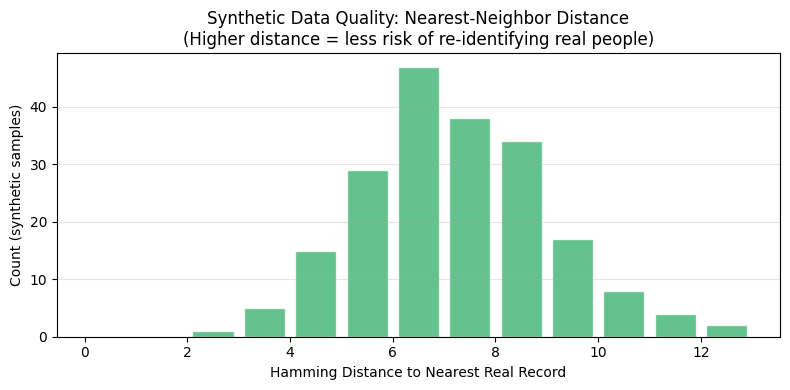

Saved: synthetic_nn_distance.png


In [33]:
# Analysis 2: Nearest-Neighbor Distance
# For each synthetic row, find the closest real row (Hamming distance)
print("Computing nearest-neighbor distances ...")

np.random.seed(42)
sample_idx  = np.random.choice(len(synth_snp_matrix), size=min(200, len(synth_snp_matrix)), replace=False)
nn_distances = []

for i in sample_idx:
    sv    = synth_snp_matrix[i]
    dists = (real_snp_matrix != sv).sum(axis=1)
    nn_distances.append(dists.min())

nn_distances = np.array(nn_distances)
print(f"\nNearest-Neighbor Distance to Real Data (50 SNPs, n=200 samples):")
print(f"  Mean  : {nn_distances.mean():.2f} SNP mismatches")
print(f"  Median: {np.median(nn_distances):.2f}")
print(f"  Min   : {nn_distances.min()}")
print(f"  Max   : {nn_distances.max()}")
print(f"  # with distance=0 (exact copies in sample): {(nn_distances==0).sum()}")

# Plot distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(nn_distances, bins=range(0, nn_distances.max()+2), color='mediumseagreen',
        edgecolor='white', alpha=0.8, rwidth=0.8)
ax.set_xlabel("Hamming Distance to Nearest Real Record")
ax.set_ylabel("Count (synthetic samples)")
ax.set_title("Synthetic Data Quality: Nearest-Neighbor Distance\n"
             "(Higher distance = less risk of re-identifying real people)")
if (nn_distances == 0).sum() > 0:
    ax.axvline(x=0, color='red', linestyle='--', label='Exact copy (distance=0)')
    ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/synthetic_nn_distance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: synthetic_nn_distance.png")

In [34]:
# Analysis 3: Linkage Attack on Synthetic Data
# Can an attacker link synthetic records back to real people in the public database?
print("Running Linkage Attack on Synthetic Data ...\n")

for n_snps in [20, 50]:
    cols = [f"SNP_{i+1}" for i in range(n_snps)]
    pub_int   = public_db_reloaded[cols].values.astype(int)
    synth_int = synth_snp_matrix[:, :n_snps]

    unique_matches = 0
    for sv in synth_int:
        dists  = (pub_int != sv).sum(axis=1)
        min_d  = dists.min()
        n_best = (dists == min_d).sum()
        if n_best == 1:
            unique_matches += 1

    total = len(synth_int)
    print(f"  SNPs={n_snps} | Synthetic unique-match rate: "
          f"{unique_matches}/{total} = {100*unique_matches/total:.1f}%")

# Save synthetic analysis summary
synth_summary = {
    'exact_copy_rate':     exact_copy_rate,
    'mean_nn_distance':    float(nn_distances.mean()),
    'median_nn_distance':  float(np.median(nn_distances)),
    'min_nn_distance':     int(nn_distances.min()),
    'exact_copies_in_sample': int((nn_distances == 0).sum()),
}
pd.DataFrame([synth_summary]).to_csv(f"{OUT_DIR}/synthetic_analysis_summary.csv", index=False)
print("\nSaved: synthetic_analysis_summary.csv")

Running Linkage Attack on Synthetic Data ...

  SNPs=20 | Synthetic unique-match rate: 666/2454 = 27.1%
  SNPs=50 | Synthetic unique-match rate: 1152/2454 = 46.9%

Saved: synthetic_analysis_summary.csv


Running MIA when target model is trained on SYNTHETIC data ...


  MIA on Synthetic-trained model (Protecting Real Members):
    AUC         : 0.4851  (Baseline No-DP: 0.8870)
    TPR@1%FPR   : 0.0059  (Baseline: 0.1600)


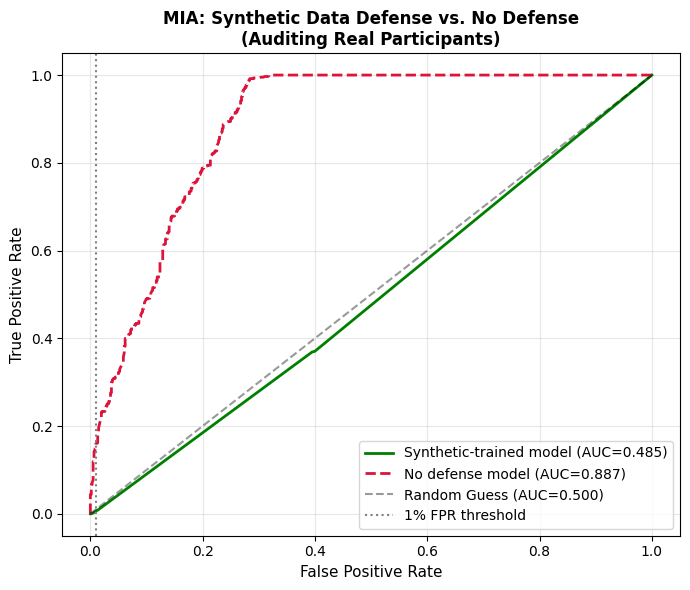

Saved: mia_synthetic_defense.png


In [45]:
# ==============================================================================
# CELL 30: REVISED MIA EVALUATION ON SYNTHETIC-TRAINED MODEL
# ==============================================================================
# Analysis 4: MIA on model trained on Synthetic Data
# True Privacy Question: Does training on synthetic data protect the REAL human participants?
print("Running MIA when target model is trained on SYNTHETIC data ...\n")

def dp_attack_features(model, X_data, y_data):
    proba = model.predict_proba(X_data)
    eps_  = 1e-12
    if hasattr(y_data, 'iloc') or isinstance(y_data, (list, np.ndarray)):
        if len(y_data) > 0 and isinstance(y_data[0], str):
            y_numeric = le.transform(y_data)
        else:
            y_numeric = np.array(y_data, dtype=int)
    else:
        y_numeric = np.array(y_data, dtype=int)
    y_idx    = np.clip(y_numeric, 0, proba.shape[1] - 1)
    p_true   = proba[np.arange(len(y_data)), y_idx]
    sorted_p = np.sort(proba, axis=1)[:, ::-1]
    loss     = -np.log(p_true + eps_)
    entropy  = -(proba * np.log(proba + eps_)).sum(axis=1)
    correct  = (proba.argmax(axis=1) == y_idx).astype(float)
    return np.column_stack([sorted_p, p_true, loss, entropy, correct])

synth_pop = synthetic_df.get('Super_Population', synthetic_df.get('Population', None))

if synth_pop is None:
    print("  Super_Population missing in synthetic data: skipping MIA-on-synthetic")
    auc_syn  = None
    tpr1_syn = None
else:
    valid_classes = set(le.classes_)
    clean_pop = synth_pop.fillna('EUR').apply(lambda x: x if x in valid_classes else 'EUR').values
    synth_pop_enc = le.transform(clean_pop)

    n_synth = len(synth_snp_matrix)
    half    = n_synth // 2

    syn_in_X, syn_in_y = synth_snp_matrix[:half], synth_pop_enc[:half]

    # Train target model strictly on synthetic data
    target_syn = make_target_model(42).fit(syn_in_X, syn_in_y)

    # TRUE PRIVACY TEST:
    # Query real participants: Members (t_in) vs. Non-members (t_out)
    t_in_y_enc  = le.transform(g["t_in"][1])  if isinstance(g["t_in"][1][0], str)  else g["t_in"][1]
    t_out_y_enc = le.transform(g["t_out"][1]) if isinstance(g["t_out"][1][0], str) else g["t_out"][1]

    F_real_in  = dp_attack_features(target_syn, g["t_in"][0],  t_in_y_enc)
    F_real_out = dp_attack_features(target_syn, g["t_out"][0], t_out_y_enc)
    F_syn      = np.vstack([F_real_in, F_real_out])
    lab_syn    = np.concatenate([np.ones(len(F_real_in)), np.zeros(len(F_real_out))])

    # Attack prediction using the trained shadow attack model
    score_syn = attack_model_learned.predict_proba(F_syn)[:, 1]
    auc_syn   = roc_auc_score(lab_syn, score_syn)
    fpr_syn, tpr_syn, _ = roc_curve(lab_syn, score_syn)
    tpr1_syn  = float(np.interp(0.01, fpr_syn, tpr_syn))

    print(f"\n  MIA on Synthetic-trained model (Protecting Real Members):")
    print(f"    AUC         : {auc_syn:.4f}  (Baseline No-DP: {mia_baseline['auc_learned']:.4f})")
    print(f"    TPR@1%FPR   : {tpr1_syn:.4f}  (Baseline: {mia_baseline['tpr1pct_learned']:.4f})")

    # Plot
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr_syn, tpr_syn, color='green', linewidth=2,
            label=f"Synthetic-trained model (AUC={auc_syn:.3f})")
    ax.plot(fpr_l, tpr_l, color='crimson', linewidth=2, linestyle='--',
            label=f"No defense model (AUC={metrics_learned['auc']:.3f})")
    ax.plot([0,1],[0,1], 'k--', alpha=0.4, label="Random Guess (AUC=0.500)")
    ax.axvline(x=0.01, color='gray', linestyle=':', label="1% FPR threshold")
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title("MIA: Synthetic Data Defense vs. No Defense\n(Auditing Real Participants)", fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/mia_synthetic_defense.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: mia_synthetic_defense.png")

    pd.DataFrame([{'auc_syn': auc_syn, 'tpr1pct_syn': tpr1_syn}]).to_csv(
        f"{OUT_DIR}/mia_synthetic_results.csv", index=False)


---
## SECTION 7: Combined Defense — DP + Synthetic Data

As specified in the Full Process document: "At last use both defenses on the data and implement the attack again and save the result."

We train a DP model (epsilon=1.0) on synthetic data, then run MIA against it.

In [47]:
# ==============================================================================
# CELL 32: REVISED COMBINED DEFENSE (DP + SYNTHETIC DATA)
# ==============================================================================
print("=== Combined Defense: DP + Synthetic Data ===")

auc_comb  = None
tpr1_comb = None

if auc_syn is not None:
    EPSILON_COMBINED = 1.0
    print(f"Training DP model (epsilon={EPSILON_COMBINED}) on synthetic training data ...")

    dp_combined = DPGaussianNB(
        epsilon=EPSILON_COMBINED,
        bounds=([0]*50, [2]*50)
    ).fit(syn_in_X.astype(float), syn_in_y)

    # Evaluate protection of real individuals
    t_in_y_enc  = le.transform(g["t_in"][1])  if isinstance(g["t_in"][1][0], str)  else g["t_in"][1]
    t_out_y_enc = le.transform(g["t_out"][1]) if isinstance(g["t_out"][1][0], str) else g["t_out"][1]

    F_comb_in  = dp_attack_features(dp_combined, g["t_in"][0],  t_in_y_enc)
    F_comb_out = dp_attack_features(dp_combined, g["t_out"][0], t_out_y_enc)
    F_comb     = np.vstack([F_comb_in, F_comb_out])
    lab_comb   = np.concatenate([np.ones(len(F_comb_in)), np.zeros(len(F_comb_out))])

    score_comb = attack_model_learned.predict_proba(F_comb)[:, 1]
    auc_comb   = roc_auc_score(lab_comb, score_comb)
    fpr_comb, tpr_comb, _ = roc_curve(lab_comb, score_comb)
    tpr1_comb  = float(np.interp(0.01, fpr_comb, tpr_comb))

    print(f"\n  Combined (DP epsilon={EPSILON_COMBINED} + Synthetic):")
    print(f"    AUC       : {auc_comb:.4f}")
    print(f"    TPR@1%FPR : {tpr1_comb:.4f}")

    pd.DataFrame([{'scenario': 'DP+Synthetic', 'epsilon': EPSILON_COMBINED,
                   'auc': auc_comb, 'tpr1pct': tpr1_comb}]).to_csv(
        f"{OUT_DIR}/combined_defense_results.csv", index=False)
    print("\nSaved: combined_defense_results.csv")
else:
    print("  Skipping combined defense (synthetic pop label unavailable).")


=== Combined Defense: DP + Synthetic Data ===
Training DP model (epsilon=1.0) on synthetic training data ...

  Combined (DP epsilon=1.0 + Synthetic):
    AUC       : 0.5014
    TPR@1%FPR : 0.0135

Saved: combined_defense_results.csv


---
## SECTION 8: Final Results Dashboard

A single, clean comparison of all attack scenarios with proper before/after charts.

In [48]:
# Reload all saved results
linkage_res = pd.read_csv(f"{OUT_DIR}/linkage_attack_results.csv")
uniq_res    = pd.read_csv(f"{OUT_DIR}/uniqueness_stats.csv")
dp_df       = pd.read_csv(f"{OUT_DIR}/dp_sweep_results.csv")

dp_summary  = dp_df.groupby('epsilon').agg(
    auc_mean=('auc','mean'), auc_std=('auc','std'),
    tpr1_mean=('tpr1pct','mean'), tpr1_std=('tpr1pct','std'),
    acc_mean=('te_acc','mean'), acc_std=('te_acc','std')
).reset_index()

best_dp = dp_summary.loc[dp_summary['auc_mean'].idxmin()]

print("=" * 60)
print(" RESULTS SUMMARY")
print("=" * 60)
print(f"\nLinkage Attack (50 SNPs, external targets):")
row50 = linkage_res[linkage_res['SNP_Count'] == 50].iloc[0]
print(f"  Unique Match Rate: {row50['Unique_Match_Rate']*100:.1f}%")

print(f"\nMembership Inference Attack (No Defense):")
print(f"  AUC (Learned)    : {mia_baseline['auc_learned']:.4f}")
print(f"  TPR@1%FPR        : {mia_baseline['tpr1pct_learned']:.4f}")

print(f"\nDifferential Privacy (best epsilon={best_dp['epsilon']:.1f}):")
print(f"  AUC              : {best_dp['auc_mean']:.4f}")
print(f"  TPR@1%FPR        : {best_dp['tpr1_mean']:.4f}")

if auc_syn is not None:
    print(f"\nSynthetic Data Defense:")
    print(f"  AUC              : {auc_syn:.4f}")
    print(f"  TPR@1%FPR        : {tpr1_syn:.4f}")

if auc_comb is not None:
    print(f"\nCombined (DP + Synthetic):")
    print(f"  AUC              : {auc_comb:.4f}")
    print(f"  TPR@1%FPR        : {tpr1_comb:.4f}")

print("=" * 60)

 RESULTS SUMMARY

Linkage Attack (50 SNPs, external targets):
  Unique Match Rate: 100.0%

Membership Inference Attack (No Defense):
  AUC (Learned)    : 0.8870
  TPR@1%FPR        : 0.1600

Differential Privacy (best epsilon=2.0):
  AUC              : 0.4912
  TPR@1%FPR        : 0.0119

Synthetic Data Defense:
  AUC              : 0.4851
  TPR@1%FPR        : 0.0059

Combined (DP + Synthetic):
  AUC              : 0.5014
  TPR@1%FPR        : 0.0135


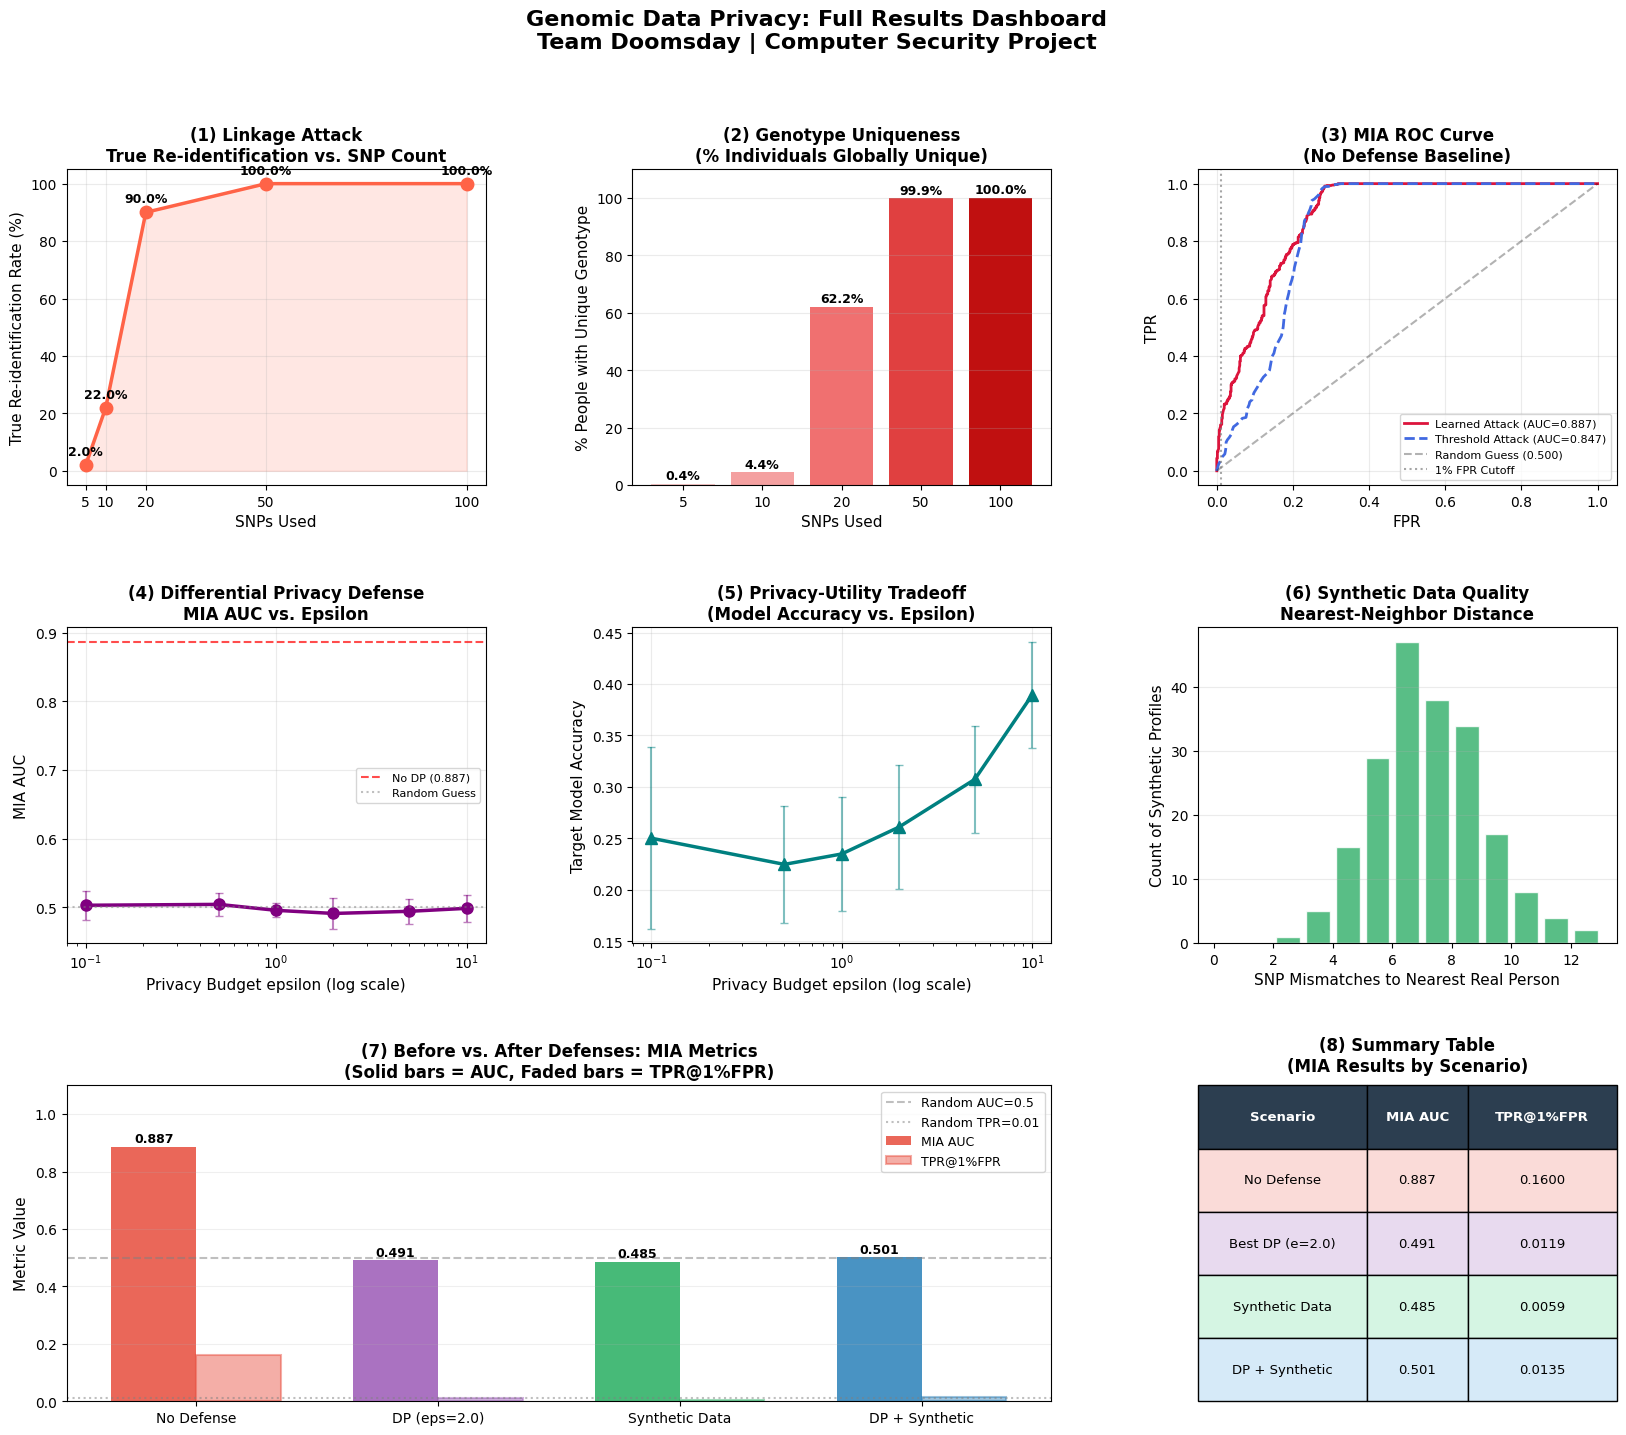

Saved: final_dashboard.png


In [49]:
# ==============================================================================
# CELL 35: REVISED FINAL RESULTS DASHBOARD
# ==============================================================================
fig = plt.figure(figsize=(20, 16))
fig.suptitle(
    "Genomic Data Privacy: Full Results Dashboard\nTeam Doomsday | Computer Security Project",
    fontsize=16, fontweight='bold', y=0.98
)

gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Chart 1: Linkage Attack: Unique Match Rate vs SNPs
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(linkage_res['SNP_Count'],
         linkage_res['Unique_Match_Rate'] * 100,
         'o-', color='tomato', linewidth=2.5, markersize=9)
ax1.fill_between(linkage_res['SNP_Count'],
                 linkage_res['Unique_Match_Rate'] * 100, alpha=0.15, color='tomato')
ax1.set_xlabel("SNPs Used", fontsize=11)
ax1.set_ylabel("True Re-identification Rate (%)", fontsize=11)
ax1.set_title("(1) Linkage Attack\nTrue Re-identification vs. SNP Count", fontweight='bold')
ax1.set_xticks(SNP_COUNTS)
ax1.grid(True, alpha=0.25)
for _, r in linkage_res.iterrows():
    ax1.annotate(f"{r['Unique_Match_Rate']*100:.1f}%",
                 (r['SNP_Count'], r['Unique_Match_Rate']*100),
                 textcoords="offset points", xytext=(0, 7), ha='center', fontsize=9, fontweight='bold')

# Chart 2: Genotype Uniqueness (Public DB)
ax2 = fig.add_subplot(gs[0, 1])
colors_bar = ['#f7c5c5','#f4a0a0','#f07070','#e04040','#c01010']
bars = ax2.bar(uniq_res['SNP_Count'].astype(str),
               uniq_res['Pct_Singleton'],
               color=colors_bar)
ax2.set_xlabel("SNPs Used", fontsize=11)
ax2.set_ylabel("% People with Unique Genotype", fontsize=11)
ax2.set_title("(2) Genotype Uniqueness\n(% Individuals Globally Unique)", fontweight='bold')
ax2.set_ylim(0, 110)
ax2.grid(True, alpha=0.25, axis='y')
for bar, val in zip(bars, uniq_res['Pct_Singleton']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"{val:.1f}%", ha='center', fontsize=9, fontweight='bold')

# Chart 3: MIA ROC curves (No Defense)
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(fpr_l, tpr_l, color='crimson', linewidth=2,
         label=f"Learned Attack (AUC={metrics_learned['auc']:.3f})")
ax3.plot(fpr_t, tpr_t, color='royalblue', linewidth=2, linestyle='--',
         label=f"Threshold Attack (AUC={metrics_thresh['auc']:.3f})")
ax3.plot([0,1],[0,1], 'k--', alpha=0.3, label="Random Guess (0.500)")
ax3.axvline(x=0.01, color='gray', linestyle=':', alpha=0.7, label="1% FPR Cutoff")
ax3.set_xlabel("FPR", fontsize=11)
ax3.set_ylabel("TPR", fontsize=11)
ax3.set_title("(3) MIA ROC Curve\n(No Defense Baseline)", fontweight='bold')
ax3.legend(fontsize=8, loc='lower right')
ax3.grid(True, alpha=0.25)

# Chart 4: DP AUC vs Epsilon
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(dp_summary['epsilon'], dp_summary['auc_mean'], 'o-', color='purple',
         linewidth=2.5, markersize=8)
ax4.errorbar(dp_summary['epsilon'], dp_summary['auc_mean'],
             yerr=dp_summary['auc_std'], fmt='none', color='purple', alpha=0.5, capsize=3)
ax4.axhline(y=mia_baseline['auc_learned'], color='red', linestyle='--',
            label=f"No DP ({mia_baseline['auc_learned']:.3f})", alpha=0.7)
ax4.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Random Guess')
ax4.set_xlabel("Privacy Budget epsilon (log scale)", fontsize=11)
ax4.set_ylabel("MIA AUC", fontsize=11)
ax4.set_title("(4) Differential Privacy Defense\nMIA AUC vs. Epsilon", fontweight='bold')
ax4.set_xscale('log')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.25)

# Chart 5: DP Privacy-Utility Tradeoff
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(dp_summary['epsilon'], dp_summary['acc_mean'], '^-', color='teal',
         linewidth=2.5, markersize=8)
ax5.errorbar(dp_summary['epsilon'], dp_summary['acc_mean'],
             yerr=dp_summary['acc_std'], fmt='none', color='teal', alpha=0.5, capsize=3)
ax5.set_xlabel("Privacy Budget epsilon (log scale)", fontsize=11)
ax5.set_ylabel("Target Model Accuracy", fontsize=11)
ax5.set_title("(5) Privacy-Utility Tradeoff\n(Model Accuracy vs. Epsilon)", fontweight='bold')
ax5.set_xscale('log')
ax5.grid(True, alpha=0.25)

# Chart 6: Synthetic Data Nearest-Neighbor Distance
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(nn_distances, bins=range(0, max(nn_distances)+2),
         color='mediumseagreen', edgecolor='white', alpha=0.85, rwidth=0.8)
ax6.set_xlabel("SNP Mismatches to Nearest Real Person", fontsize=11)
ax6.set_ylabel("Count of Synthetic Profiles", fontsize=11)
ax6.set_title("(6) Synthetic Data Quality\nNearest-Neighbor Distance", fontweight='bold')
if (nn_distances == 0).sum() > 0:
    ax6.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Exact copies')
    ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.25, axis='y')

# Chart 7: Before/After MIA AUC Summary
ax7 = fig.add_subplot(gs[2, 0:2])
scenarios = ['No Defense']
aucs      = [mia_baseline['auc_learned']]
tprs      = [mia_baseline['tpr1pct_learned']]

scenarios.append(f"DP (eps={best_dp['epsilon']:.1f})")
aucs.append(best_dp['auc_mean'])
tprs.append(best_dp['tpr1_mean'])

if auc_syn is not None:
    scenarios.append("Synthetic Data")
    aucs.append(auc_syn)
    tprs.append(tpr1_syn)

if auc_comb is not None:
    scenarios.append("DP + Synthetic")
    aucs.append(auc_comb)
    tprs.append(tpr1_comb)

colors_bar2 = ['#e74c3c', '#9b59b6', '#27ae60', '#2980b9'][:len(scenarios)]
x     = np.arange(len(scenarios))
width = 0.35

bars_auc = ax7.bar(x - width/2, aucs, width, label='MIA AUC', color=colors_bar2, alpha=0.85)
bars_tpr = ax7.bar(x + width/2, tprs, width, label='TPR@1%FPR',
                   color=colors_bar2, alpha=0.45, edgecolor=colors_bar2, linewidth=1.5)

ax7.axhline(y=0.5,  color='gray', linestyle='--', alpha=0.5, label='Random AUC=0.5')
ax7.axhline(y=0.01, color='gray', linestyle=':',  alpha=0.5, label='Random TPR=0.01')
ax7.set_xticks(x)
ax7.set_xticklabels(scenarios, fontsize=10)
ax7.set_ylabel("Metric Value", fontsize=11)
ax7.set_ylim(0, 1.1)
ax7.set_title("(7) Before vs. After Defenses: MIA Metrics\n(Solid bars = AUC, Faded bars = TPR@1%FPR)",
              fontweight='bold')
ax7.legend(fontsize=9, loc='upper right')
ax7.grid(True, alpha=0.2, axis='y')
for bar in bars_auc:
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f"{bar.get_height():.3f}", ha='center', fontsize=9, fontweight='bold')

# Chart 8: Summary Table
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
table_data = [
    ["No Defense", f"{mia_baseline['auc_learned']:.3f}",
     f"{mia_baseline['tpr1pct_learned']:.4f}"],
    [f"Best DP (e={best_dp['epsilon']:.1f})",
     f"{best_dp['auc_mean']:.3f}", f"{best_dp['tpr1_mean']:.4f}"],
]
if auc_syn is not None:
    table_data.append(["Synthetic Data", f"{auc_syn:.3f}", f"{tpr1_syn:.4f}"])
if auc_comb is not None:
    table_data.append(["DP + Synthetic", f"{auc_comb:.3f}", f"{tpr1_comb:.4f}"])

tbl = ax8.table(
    cellText=table_data,
    colLabels=["Scenario", "MIA AUC", "TPR@1%FPR"],
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.auto_set_column_width([0, 1, 2])
for j in range(3):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
row_colors = ['#fadbd8', '#e8daef', '#d5f5e3', '#d6eaf8']
for i in range(len(table_data)):
    for j in range(3):
        tbl[i+1, j].set_facecolor(row_colors[i % len(row_colors)])

ax8.set_title("(8) Summary Table\n(MIA Results by Scenario)",
              fontweight='bold', pad=10)

plt.savefig(f"{OUT_DIR}/final_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: final_dashboard.png")


---
## SECTION 9: All Output Files Summary

In [50]:
import os

output_files = [
    "public_database.csv",
    "external_targets.csv",
    "linkage_attack_results.csv",
    "uniqueness_stats.csv",
    "linkage_attack_plot.png",
    "mia_no_defense_results.csv",
    "mia_roc_no_defense.png",
    "dp_sweep_results.csv",
    "dp_epsilon_sweep.png",
    "synthetic_data.csv",
    "synthetic_analysis_summary.csv",
    "synthetic_nn_distance.png",
    "mia_synthetic_results.csv",
    "mia_synthetic_defense.png",
    "combined_defense_results.csv",
    "final_dashboard.png",
]

print("=" * 60)
print(" OUTPUT FILES SUMMARY")
print("=" * 60)
for fname in output_files:
    fpath = f"{OUT_DIR}/{fname}"
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  OK  {fname:<45}  ({size_kb:.1f} KB)")
    else:
        print(f"  MISSING  {fname}")
print("=" * 60)
print("\nExperiment complete. All results saved to /kaggle/working/")

 OUTPUT FILES SUMMARY
  OK  public_database.csv                            (572.1 KB)
  OK  external_targets.csv                           (12.4 KB)
  OK  linkage_attack_results.csv                     (0.2 KB)
  OK  uniqueness_stats.csv                           (0.2 KB)
  OK  linkage_attack_plot.png                        (89.7 KB)
  OK  mia_no_defense_results.csv                     (0.2 KB)
  OK  mia_roc_no_defense.png                         (94.9 KB)
  OK  dp_sweep_results.csv                           (2.0 KB)
  OK  dp_epsilon_sweep.png                           (121.4 KB)
  OK  synthetic_data.csv                             (273.0 KB)
  OK  synthetic_analysis_summary.csv                 (0.1 KB)
  OK  synthetic_nn_distance.png                      (46.3 KB)
  OK  mia_synthetic_results.csv                      (0.1 KB)
  OK  mia_synthetic_defense.png                      (104.6 KB)
  OK  combined_defense_results.csv                   (0.1 KB)
  OK  final_dashboard.png           